In [1]:
%load_ext autoreload
%autoreload 2

from os import path
from glob import glob
import itertools

from tqdm.auto import tqdm
import numpy as np
import pandas as pd
from scipy.stats import linregress, ttest_rel, wilcoxon
from scipy.integrate import cumulative_trapezoid as cumtrapz
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import mne

from notifmmn import erputils, datautils, statsutils, plotutils

from notifmmn.defs import *

%matplotlib widget

In [2]:
participants = pd.read_csv('participant_details.csv', index_col=0)
tones = participants[['SN_tone', 'Tone_delay']].sort_values('Tone_delay')['SN_tone'].unique() # tones sorted by delay
delays = participants['Tone_delay'].rename('tone delay')
# vibration N1 seems to come quite late but strong, so adjust their window location
delays.loc[delays[delays>0.1].index] = 0.23

# normalize the participant information
participants = participants.rename(dict(b1_deviant='b1', b2_deviant='b2', b3_deviant='b3'), axis=1)
participants['b1'] = participants['b1'].map(dict(BT='BN/SN', SN='SN/BN', CN='CN/CN')).fillna('x/x')
participants['b2'] = participants['b2'].map(dict(BT='BN/SN', SN='SN/BN', CN='CN/CN')).fillna('x/x')
participants['b3'] = participants['b3'].map(dict(BT='BN/SN', SN='SN/BN', CN='CN/CN')).fillna('x/x')
participants.head()

,age,is_controlled_block,gender,profession,b1,b2,b3,comments,SN_tone,Tone_delay,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
participant_id,,,,,,,,,,,,,,
sd011,30.0,N,M,PG_acd,SN/BN,BN/SN,x/x,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617,NaN,NaN,NaN,NaN
sd012,25.0,N,M,PG_acd,SN/BN,BN/SN,x/x,No bad channel,Whoop_doop,0.036576,NaN,NaN,NaN,NaN
sd013,25.0,N,M,PG_acd,SN/BN,BN/SN,x/x,TP10 noisy channel interpolated and further r...,Hello_inMoto,0.008617,NaN,NaN,NaN,NaN
sd014,28.0,N,M,PG_acd,SN/BN,BN/SN,x/x,bad electrode = None Bad subject only very few...,droplet,0.034830,NaN,NaN,NaN,NaN
sd015,31.0,N,M,PG_acd,SN/BN,BN/SN,x/x,bad electrode = None,realme_fun,0.006780,NaN,NaN,NaN,NaN


In [3]:
# list all preprocessed files
# preprocessing involves manual curation, band pass filtering,
# down sampling, removal of eye artifacts, and epoching
files = sorted(glob(path.join(rawdir, 'preprocessed', '*')))
print(len(files), 'files available for analysis.')
# sorted(files)

57 files available for analysis.


In [56]:
# load the data for some participant
fname = '../data/raw/preprocessed/sub-sd041-epo.fif'
sub = path.basename(fname).split('-')[1]
epochs = mne.read_epochs(fname, verbose='ERROR').apply_baseline(verbose='ERROR')

# Compute ERP scores

## N1 and P2 scores

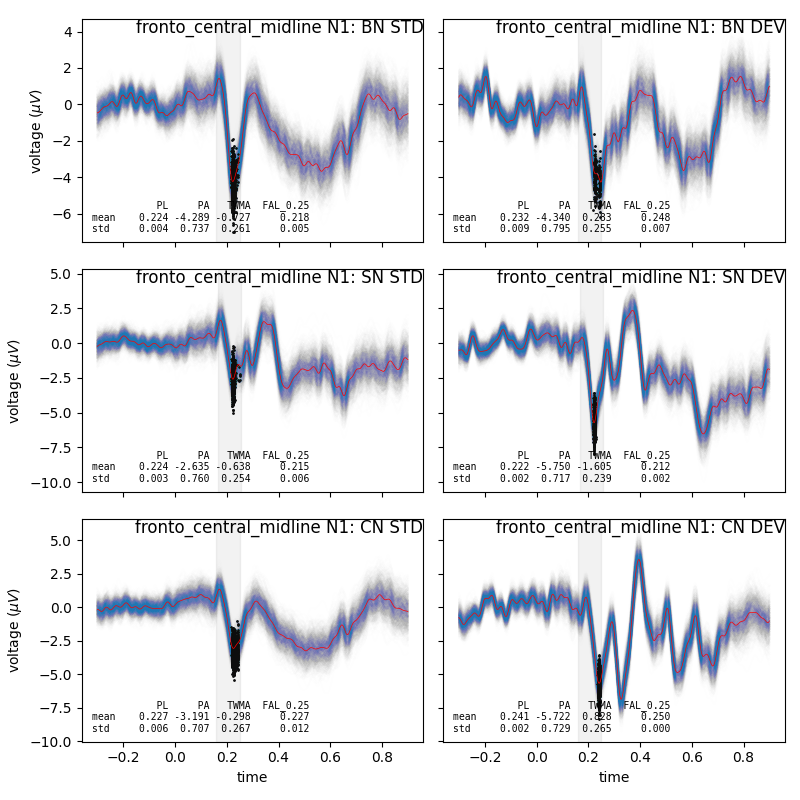

In [57]:
# get N1 scores

nsamples = [150]
niter = 1000
latency_fracs = [0.5]
electrodes = 'fronto_central_midline' # can be 'fronto_central_midline', 'supratemporal', 'right_frontal'
n1_win = np.array([0.16, 0.25])

f, axes = plt.subplots(3, 2, figsize=(8, 8), tight_layout=True, sharex='col', sharey='row')
n1_scores, n1_erps = {}, {}
for (stim, stim_type), ax in zip(itertools.product(stims, stim_types), axes.flatten()):
    try:
        n1_scores[(stim, stim_type)], n1_erps[(stim, stim_type)], f = erputils.get_erp_sem(
            epochs[triggers[f'{stim} {stim_type}']],
            n_iterations=niter, sample_size=nsamples, window=n1_win+(delays.loc[sub] if stim=='SN' else 0),
            picks=locations[electrodes], ax=ax
        )
        ax.set_title(f'{electrodes} N1: {stim} {stim_type}', y=0.9, loc='right')
        n1_erps[(stim, stim_type)].mean(axis=1).plot(ax=ax, color='r', lw=0.5)
    except:
        pass
n1_scores = pd.concat(n1_scores, names=['stim', 'stim_type', 'iteration'])
n1_erps = pd.concat(n1_erps, names=['stim', 'stim_type', 'time'])

# compute mean and SEM of N1 scores
n1_agg = n1_scores.groupby(['stim', 'stim_type']).agg(['mean', 'std'])
n1_agg.columns = ['_'.join(c) for c in n1_agg.columns]

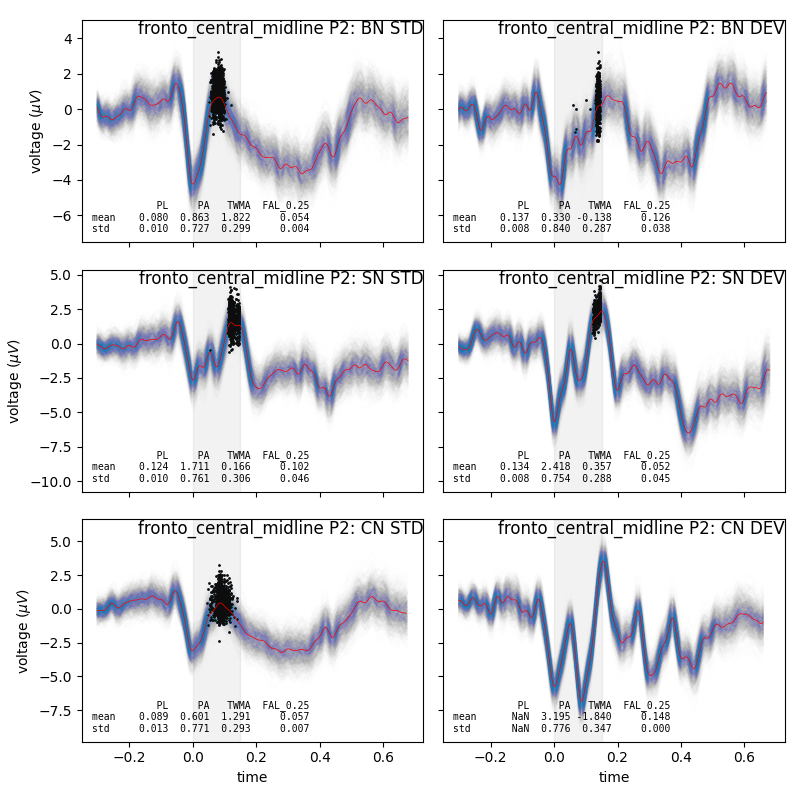

In [58]:
# get P2 scores (align ERPs wrt N1 peak)
# IMPROVEMENT NEEDED: Locate the first peak in the window

nsamples = [150]
niter = 1000
latency_fracs = [0.5]
electrodes = 'fronto_central_midline' # can be 'fronto_central_midline', 'supratemporal', 'right_frontal'
p2_win = np.array([0, 0.15]) # offset wrt N1 peak

f, axes = plt.subplots(3, 2, figsize=(8, 8), tight_layout=True, sharex='col', sharey='row')
p2_scores, p2_erps = {}, {}
for (stim, stim_type), ax in zip(itertools.product(stims, stim_types), axes.flatten()):
    try:
        p2_scores[(stim, stim_type)], p2_erps[(stim, stim_type)], f = erputils.get_erp_sem(
            epochs[triggers[f'{stim} {stim_type}']],
            n_iterations=niter, sample_size=nsamples,
            window=p2_win, offsets=-int(n1_agg.loc[(stim, stim_type), 'PL_mean']*sfreq),
            picks=locations[electrodes], extrema=1, ax=ax
        )
        ax.set_title(f'{electrodes} P2: {stim} {stim_type}', y=0.9, loc='right')
        p2_erps[(stim, stim_type)].mean(axis=1).plot(ax=ax, color='r', lw=0.5)
    except Exception as e:
        print(e)
p2_scores = pd.concat(p2_scores, names=['stim', 'stim_type', 'iteration'])
p2_erps = pd.concat(p2_erps, names=['stim', 'stim_type', 'time'])

# compute mean and SEM of N1 scores
p2_agg = p2_scores.groupby(['stim', 'stim_type']).agg(['mean', 'std'])
p2_agg.columns = ['_'.join(c) for c in p2_agg.columns]

## MMN scores

### Simple DEV - STD

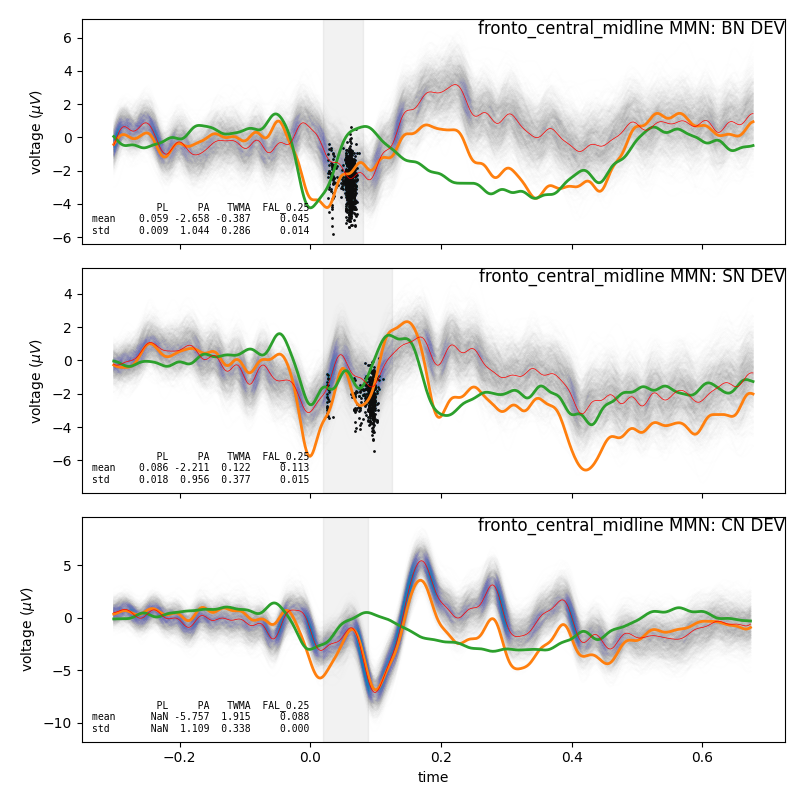

In [59]:
# get MMN scores (align ERPs wrt N1 peak)
# restrict MMN window from N1 peak (t=0) to 50 ms post P2 peak

nsamples = [150, 150]
niter = 1000
latency_fracs = [0.5]
electrodes = 'fronto_central_midline' # can be 'fronto_central_midline', 'supratemporal', 'right_frontal'
mmn_win = np.array([0.02, 0.0]) # onset wrt N1 peak, offset wrt p2

f, axes = plt.subplots(3, 1, figsize=(8, 8), tight_layout=True, sharex='col', sharey='row')
mmn_scores, mmn_erps = {}, {}
for stim, ax in zip(stims, axes.flatten()):
    try:
        epochs_to_use = [epochs[triggers[f'{stim} DEV']], epochs[triggers[f'{stim} STD']]]
        offsets = -int(n1_agg.loc[(stim, 'STD'), 'PL_mean']*sfreq)
        mmn_scores[(stim, stim_type)], mmn_erps[(stim, stim_type)], f = erputils.get_erp_sem(
            epochs_to_use,
            n_iterations=niter, sample_size=nsamples,
            window=(mmn_win[0], mmn_win[1]+p2_agg.loc[(stim, 'STD'), 'PL_mean']),
            picks=locations[electrodes], extrema=-1, offsets=offsets, ax=ax
        )
        ax.set_title(f'{electrodes} MMN: {stim} {stim_type}', y=0.9, loc='right')
        mmn_erps[(stim, stim_type)].mean(axis=1).plot(ax=ax, color='r', lw=0.5)
    except:
        pass
mmn_scores = pd.concat(mmn_scores, names=['stim', 'stim_type', 'iteration'])
mmn_erps = pd.concat(mmn_erps, names=['stim', 'stim_type', 'time'])

### Fractional area difference peak
We will use the integrated area between P1 and P2 and see how the fractional area covered increases from P1 to P2. Before the MMN, DEV should cover less area, and this shortfall will be covered during the MMN.

In [60]:
# find P1 and P2 locations for the given trial
def _get_p1_p2(zero_aligned_erp):
    # find P1 peak
    p1_idx = zero_aligned_erp.droplevel('stim_type').loc[-0.075:0].idxmax()
    # find P2 peak
    p2_idx = zero_aligned_erp.droplevel('stim_type').loc[0.05:0.125].idxmax()
    return pd.Series([p1_idx, p2_idx])

def _get_fa(zero_aligned_erp):
    indices = zero_aligned_erp.groupby('stim_type').apply(_get_p1_p2).unstack()
    p1_idx = indices[0].max()
    p2_idx = indices[1].max()
    # compute fractional area between P1 and P2
    area = zero_aligned_erp.groupby('stim_type').apply(
        lambda x: pd.Series(cumtrapz(
            x.droplevel('stim_type').loc[p1_idx:p2_idx],
            x.droplevel('stim_type').loc[p1_idx:p2_idx].index, initial=0
        ), index=x.droplevel('stim_type').loc[p1_idx:p2_idx].index)
    )
    return (area.unstack('stim_type') - area.unstack('stim_type').max())

def _get_fa_diff(zero_aligned_erp):
    cuma = _get_fa(zero_aligned_erp)
    return (cuma / cuma.ffill().iloc[-1]).diff(axis=1)['STD'].rename('fa_diff')


In [61]:
diffs = p2_erps.groupby('stim').apply(lambda df: df.droplevel('stim').apply(_get_fa_diff))

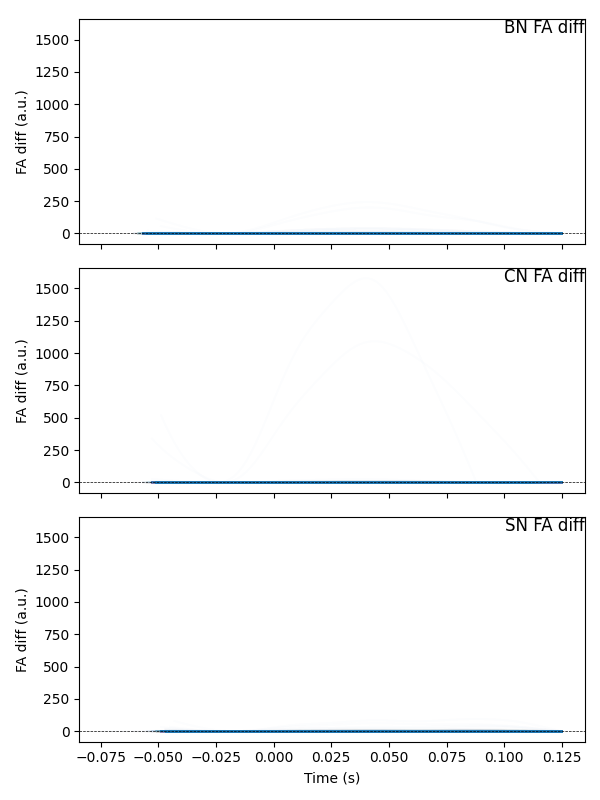

In [62]:
f, axes = plt.subplots(3, 1, figsize=(6, 8), tight_layout=True, sharex=True, sharey=True)
for (stim, df), ax in zip(diffs.groupby('stim'), axes.flatten()):
    df.droplevel('stim').plot(ax=ax, legend=False, alpha=0.01, c='C0')
    ax.set_title(f'{stim} FA diff', y=0.9, loc='right')
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_ylabel('FA diff (a.u.)')
    ax.set_xlabel('Time (s)')

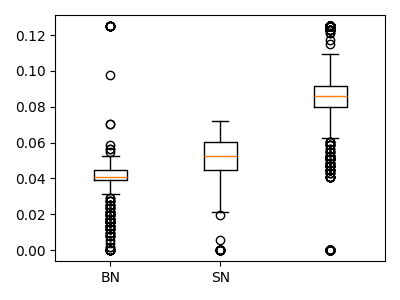

In [63]:
diff_scores = diffs.groupby('stim').apply(lambda df: df.droplevel('stim').loc[0:].idxmax())
f, ax = plt.subplots(1, 1, figsize=(4, 3), tight_layout=True)
diff_scores
ax.boxplot(diff_scores.T)
ax.set_xticks([1, 2])
ax.set_xticklabels(['BN', 'SN']);

<Axes: xlabel='time'>

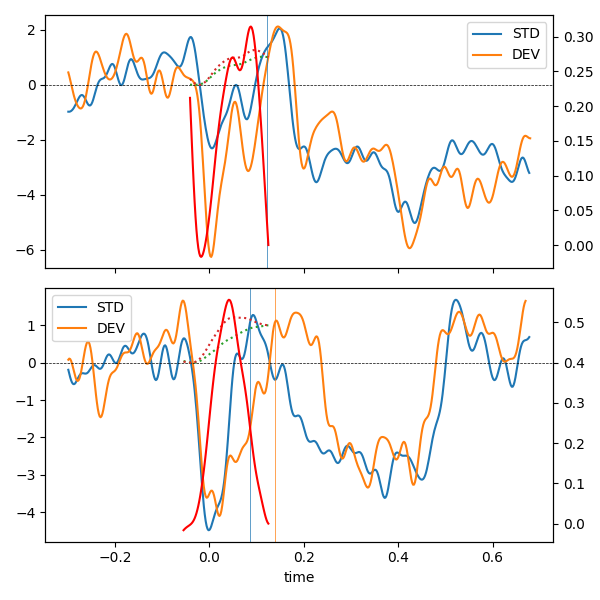

In [64]:
itr = 80
f, (axs, axb) = plt.subplots(2, 1, figsize=(6, 6), tight_layout=True, sharex=True)
p2_erps.loc['SN'][itr].unstack('stim_type').sort_index(ascending=False, axis=1).rolling(2, center=True).mean().plot(ax=axs)
axs.axhline(0, color='k', lw=0.5, ls='--')
for i, v in enumerate(p2_scores.loc['SN']['PL'].unstack('iteration')[0].sort_index(ascending=False).values):
    axs.axvline(v, lw=0.5, c=f'C{i}')
axs.legend(loc=2)
# ax2 = ax.twinx()
cuma = _get_fa(p2_erps.loc['SN'][itr])
cuma.apply(lambda x: (x/x.iloc[-1]).plot(ax=axs, ls='dotted'))
axs3 = axs.twinx()
(cuma / cuma.iloc[-1]).diff(axis=1).plot(ax=axs3, c='r', legend=False)


p2_erps.loc['BN'][itr].unstack('stim_type').sort_index(ascending=False, axis=1).rolling(2, center=True).mean().plot(ax=axb)
axb.axhline(0, color='k', lw=0.5, ls='--')
for i, v in enumerate(p2_scores.loc['BN']['PL'].unstack('iteration')[0].sort_index(ascending=False).values):
    axb.axvline(v, lw=0.5, c=f'C{i}')
axb.legend(loc=2)
# ax2 = ax.twinx()
cuma = _get_fa(p2_erps.loc['BN'][itr])
cuma.apply(lambda x: (x/x.iloc[-1]).plot(ax=axb, ls='dotted'))
axb3 = axb.twinx()
(cuma / cuma.iloc[-1]).diff(axis=1).plot(ax=axb3, c='r', legend=False)

### Correlation STD vs DEV

1.5001705019703666


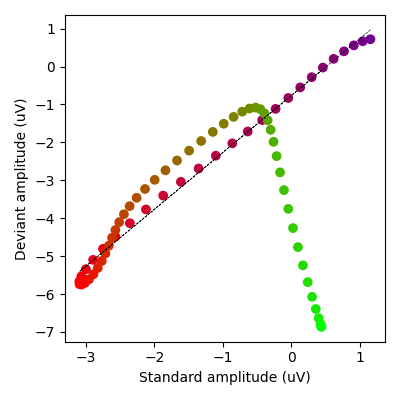

In [69]:
data = p2_erps.loc['CN'].mean(axis=1).unstack().T.loc[
    -0.05:p2_agg.loc['CN'].loc['STD']['PL_mean']
][['STD', 'DEV']]

m, c = np.polyfit(*data.loc[:0].values.T, 1)

f, ax = plt.subplots(1, 1, figsize=(4, 4), tight_layout=True)
plt.scatter(*data.values.T, c=data.index, cmap='brg', norm=colors.CenteredNorm())
plt.plot(data['STD'], m*data['STD']+c, color='k', lw=0.5, ls='--')
plt.xlabel('Standard amplitude (uV)')
plt.ylabel('Deviant amplitude (uV)')

print(m)

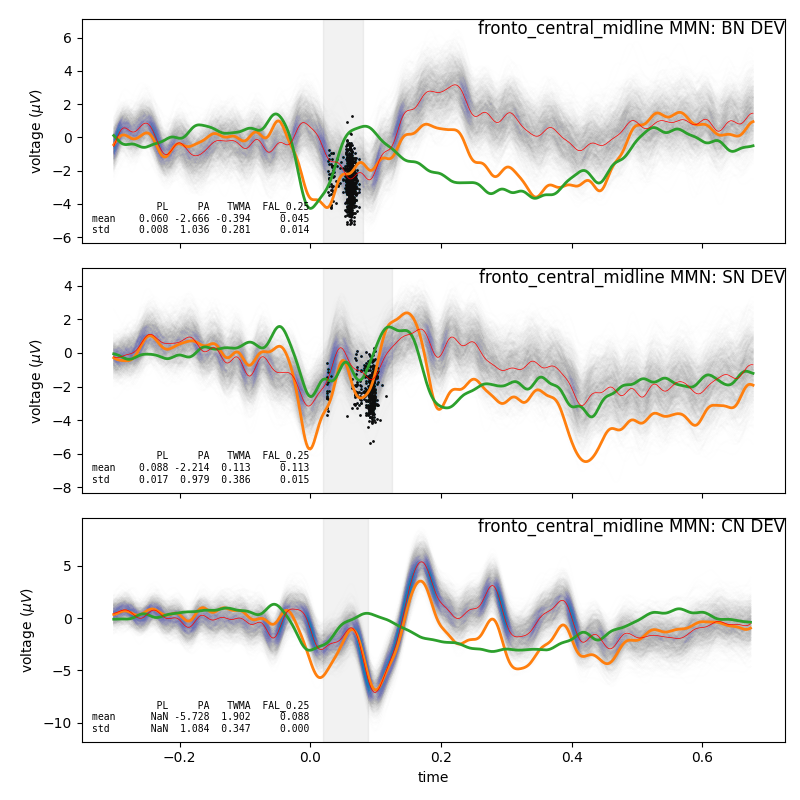

In [66]:
# get MMN scores (align ERPs wrt N1 peak)
# restrict MMN window from N1 peak (t=0) to 50 ms post P2 peak

nsamples = [150, 150]
niter = 1000
latency_fracs = [0.5]
electrodes = 'fronto_central_midline' # can be 'fronto_central_midline', 'supratemporal', 'right_frontal'
mmn_win = np.array([0.02, 0.0]) # onset wrt N1 peak, offset wrt p2

f, axes = plt.subplots(3, 1, figsize=(8, 8), tight_layout=True, sharex='col', sharey='row')
mmn_scores, mmn_erps = {}, {}
for stim, ax in zip(stims, axes.flatten()):
    try:
        epochs_to_use = [epochs[triggers[f'{stim} DEV']], epochs[triggers[f'{stim} STD']]]
        offsets = -int(n1_agg.loc[(stim, 'STD'), 'PL_mean']*sfreq)
        mmn_scores[(stim, stim_type)], mmn_erps[(stim, stim_type)], f = erputils.get_erp_sem(
            epochs_to_use,
            n_iterations=niter, sample_size=nsamples,
            window=(mmn_win[0], mmn_win[1]+p2_agg.loc[(stim, 'STD'), 'PL_mean']),
            picks=locations[electrodes], extrema=-1, offsets=offsets, ax=ax
        )
        ax.set_title(f'{electrodes} MMN: {stim} {stim_type}', y=0.9, loc='right')
        mmn_erps[(stim, stim_type)].mean(axis=1).plot(ax=ax, color='r', lw=0.5)
    except:
        pass
mmn_scores = pd.concat(mmn_scores, names=['stim', 'stim_type', 'iteration'])
mmn_erps = pd.concat(mmn_erps, names=['stim', 'stim_type', 'time'])